In [1]:
import sys
sys.path.append("..")

In [2]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
def plot_histogram(data, title, xlabel, use_log=False):
    num_bins = 50

    data = np.asarray(data)
    data = data[np.isfinite(data)]

    if use_log:
        data = data[data > 0]

    xmin = data.min()
    xmax = data.max()

    print(f"{xlabel}: Min: {xmin}, Max: {xmax}, Mean: {data.mean()}, Median: {np.median(data)}, Std: {data.std()}")

    def format_tick(x):
        return f"{x:.2e}" if abs(x) < 1e-3 or abs(x) > 1e4 else f"{x:.3g}"

    fig, ax = plt.subplots(figsize=(15, 8))

    if use_log:
        bins = np.logspace(np.log10(xmin), np.log10(xmax), num_bins + 1)
        ax.hist(data, bins=bins, alpha=0.7)
        ax.set_xscale("log")

        ticks = np.geomspace(xmin, xmax, 6)
        ax.set_xlabel(f"{xlabel} (log scale)")
    else:
        ax.hist(data, bins=num_bins, alpha=0.7)

        ticks = np.linspace(xmin, xmax, 6)
        ax.set_xlabel(xlabel)

    # Force min/max dans les graduations
    ticks = np.unique(np.concatenate(([xmin], ticks, [xmax])))

    ax.set_xlim(xmin, xmax)
    ax.set_xticks(ticks)
    ax.set_xticklabels([format_tick(t) for t in ticks], rotation=30, ha="right")

    # Lignes verticales pour rendre min/max visibles
    ax.axvline(xmin, color="black", linestyle="--", linewidth=1)
    ax.axvline(xmax, color="black", linestyle="--", linewidth=1)

    ax.set_title(title)
    ax.set_ylabel("Frequency")
    ax.grid(True, which="both" if use_log else "major")
    fig.tight_layout()
    plt.show()

In [4]:
def load_and_plot_amp_snr(file_path):
    params = {}
    with h5py.File(file_path, "r") as f:
        for key, value in f['params'].items():
            if key in ["amp", "snr"]:
                params[key] = value[:]

    min_amp = params['amp'].min()
    max_amp = params['amp'].max()
    size = params['amp'].shape[0]

    plot_histogram(params['amp'], f"Dataset Size {size}, Amplitude Min: {min_amp:.2e}, Amplitude Max: {max_amp:.2e} - Distribution of Amplitude", "Amplitude", use_log=False)
    plot_histogram(params['snr'], f"Dataset Size {size}, Amplitude Min: {min_amp:.2e}, Amplitude Max: {max_amp:.2e} - Distribution of SNR", "SNR", use_log=False)

Amplitude: Min: 2.0000001574120985e-23, Max: 1.4999993213095596e-22, Mean: 7.207996902580982e-23, Median: 6.940266977679833e-23, Std: 3.743392066509216e-23


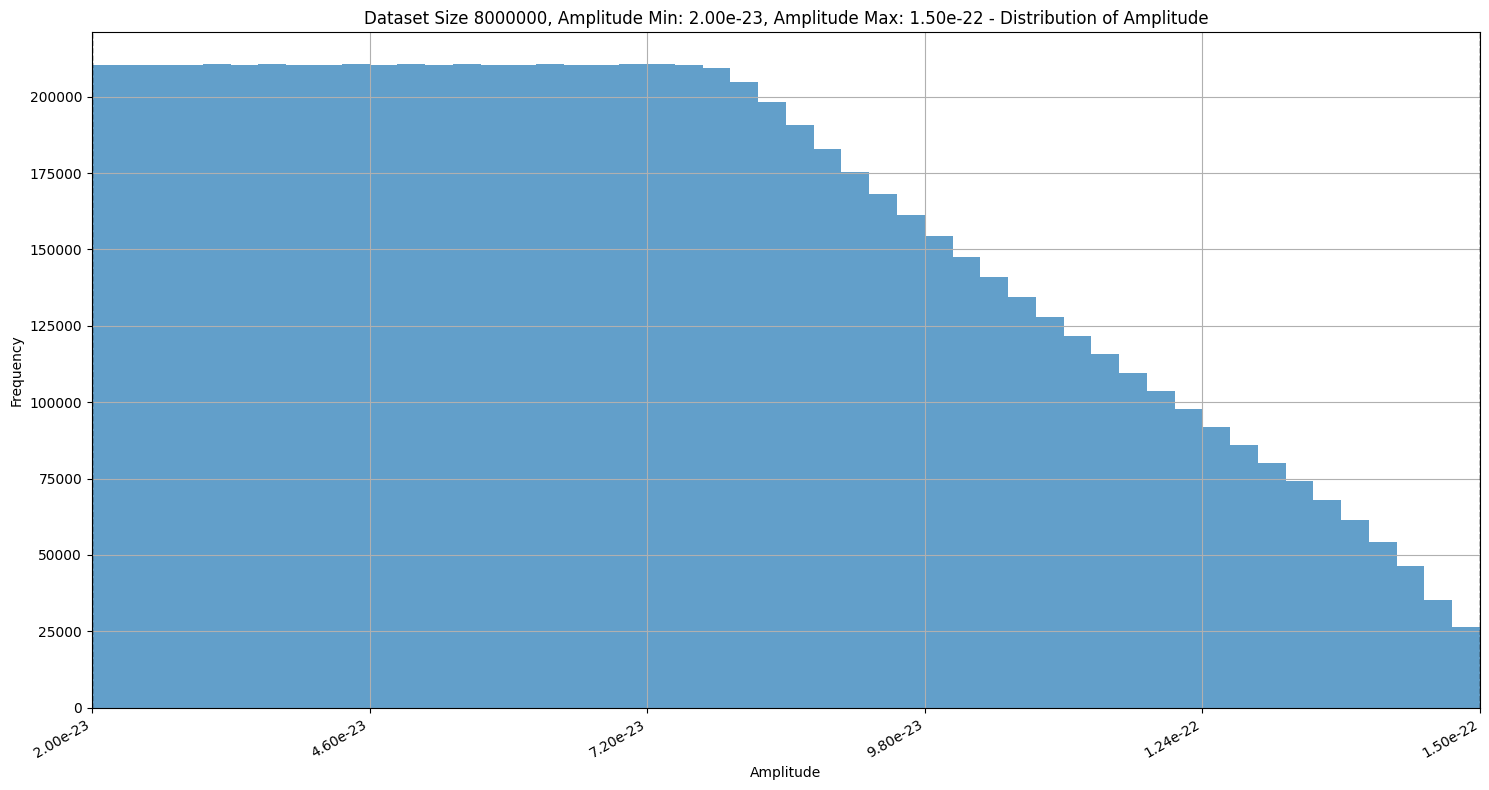

SNR: Min: 10.00025463104248, Max: 99.99999237060547, Mean: 57.691471099853516, Median: 57.65460205078125, Std: 24.0


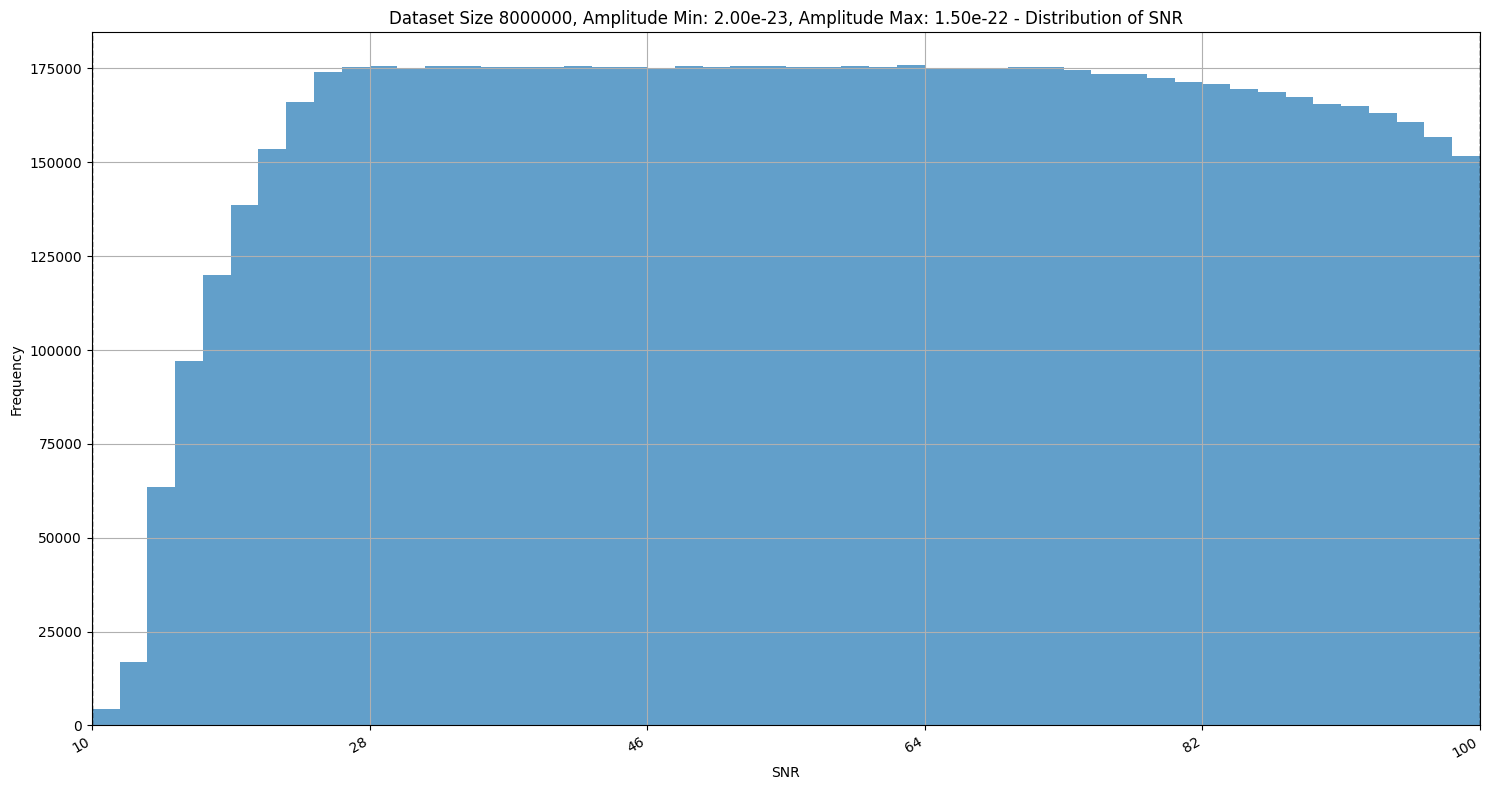

In [22]:
file_path = "../data/synthetic_dataset/dataset_8M_2.0e-23_1.5e-22_filtering_True_10_100_difficulty_1/dataset.hdf5"
load_and_plot_amp_snr(file_path)

Amplitude: Min: 2.0000011040451848e-23, Max: 9.999999051566501e-23, Mean: 5.875424031400337e-23, Median: 5.854563393622672e-23, Std: 0.0


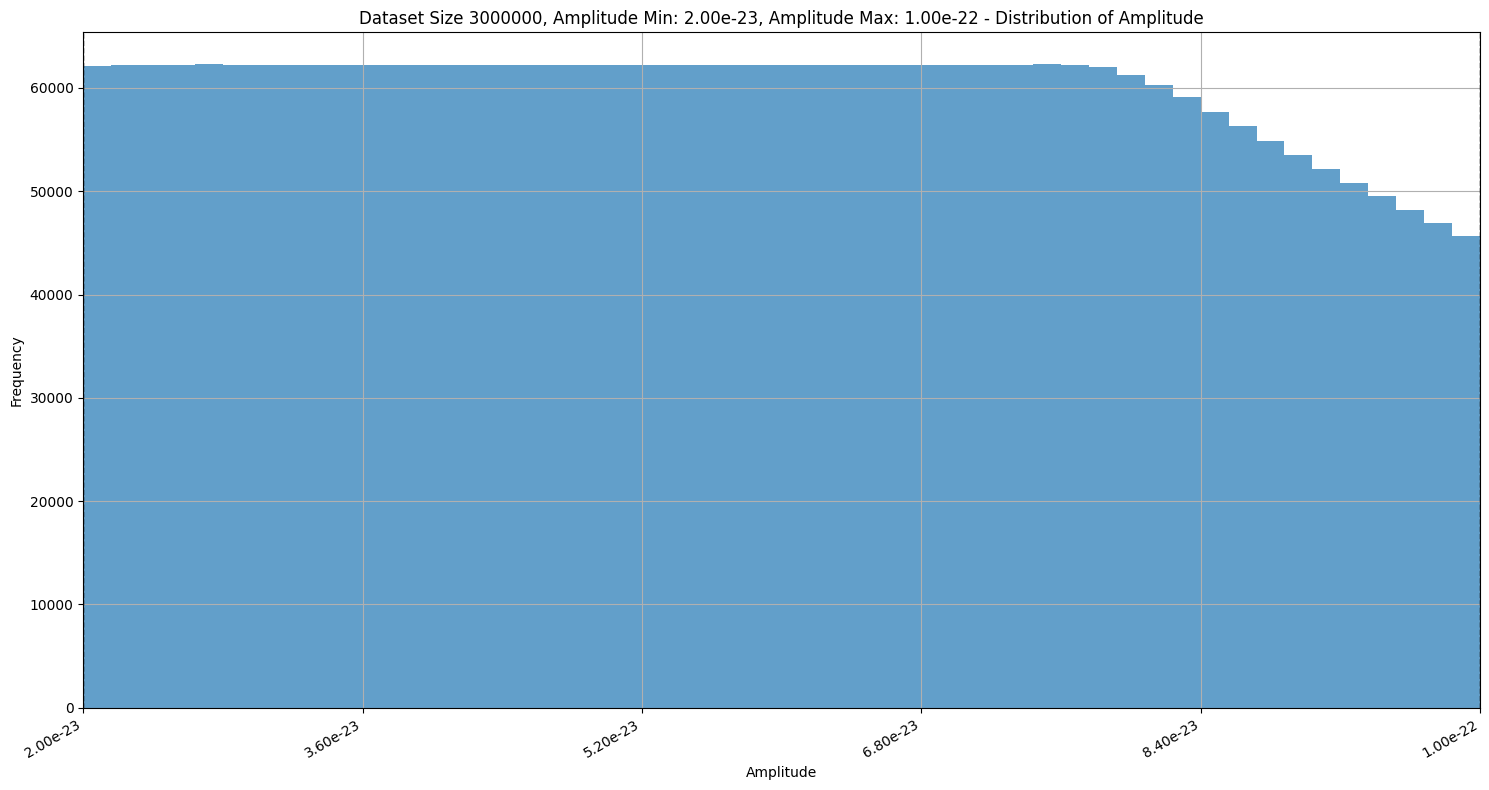

SNR: Min: 10.000731468200684, Max: 99.99983215332031, Mean: 50.10049057006836, Median: 48.64142608642578, Std: 21.137380599975586


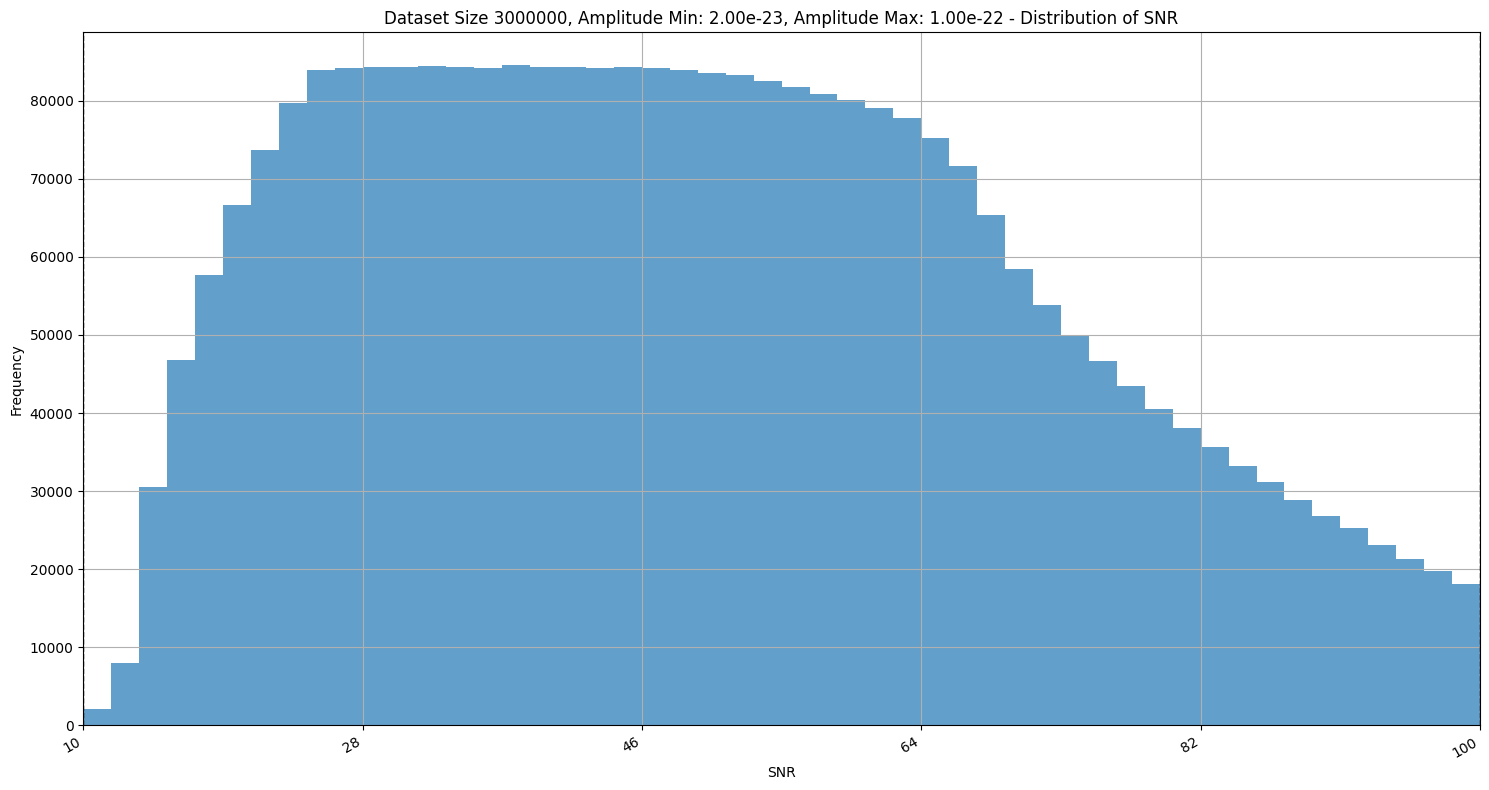

In [23]:
file_path = "../data/synthetic_dataset/dataset_3M_2.0e-23_1.0e-22_filtering_True_10_100_difficulty_1/dataset.hdf5" # Keys : 'params', 'waveforms' 
load_and_plot_amp_snr(file_path)

Amplitude: Min: 5.000270183959832e-24, Max: 1.9999996840955554e-22, Mean: 9.15279651815024e-23, Median: 8.920507273821413e-23, Std: 5.293955920339377e-23


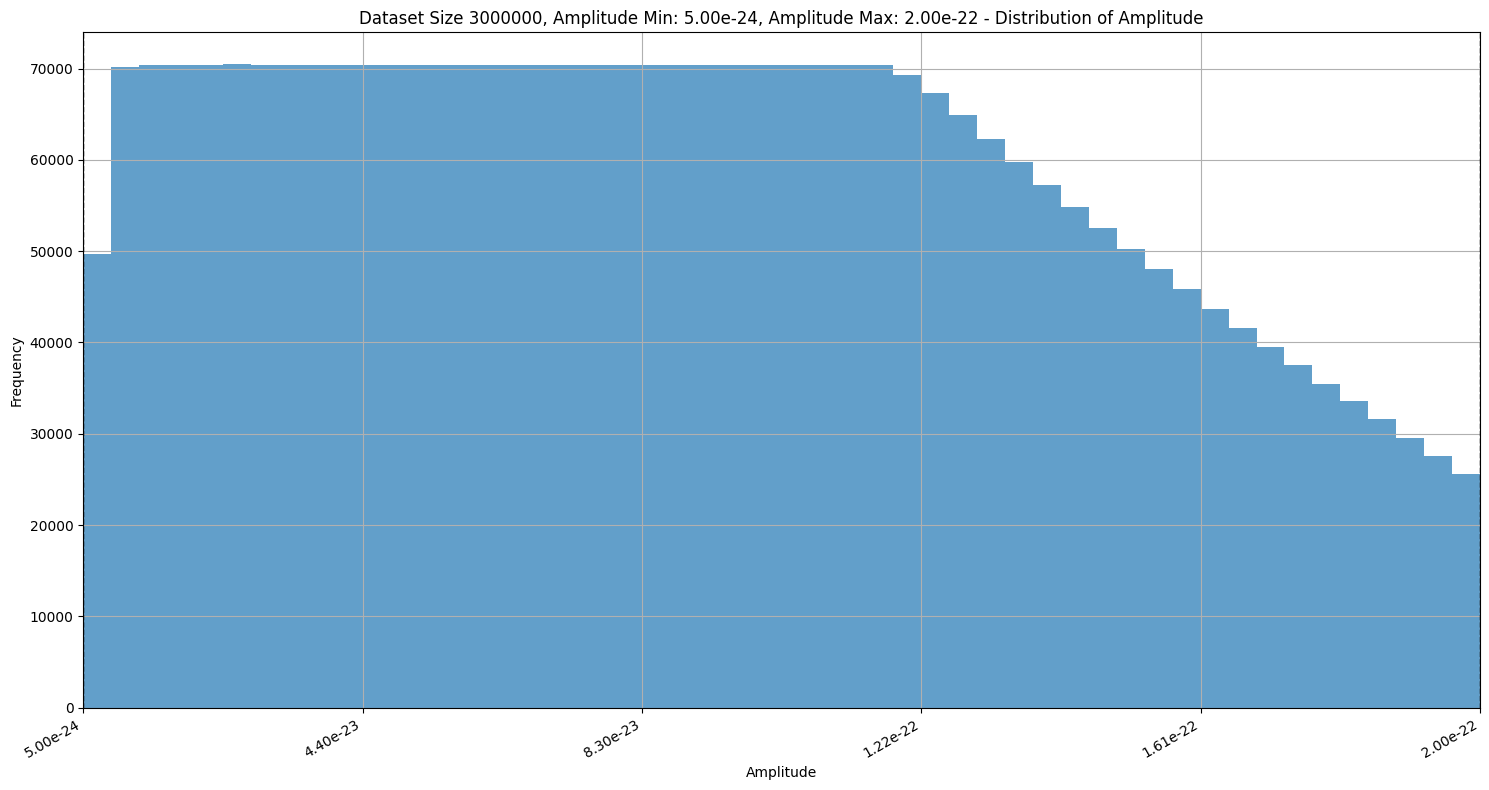

SNR: Min: 5.0000834465026855, Max: 149.99989318847656, Mean: 74.53939056396484, Median: 74.10546875, Std: 40.49605941772461


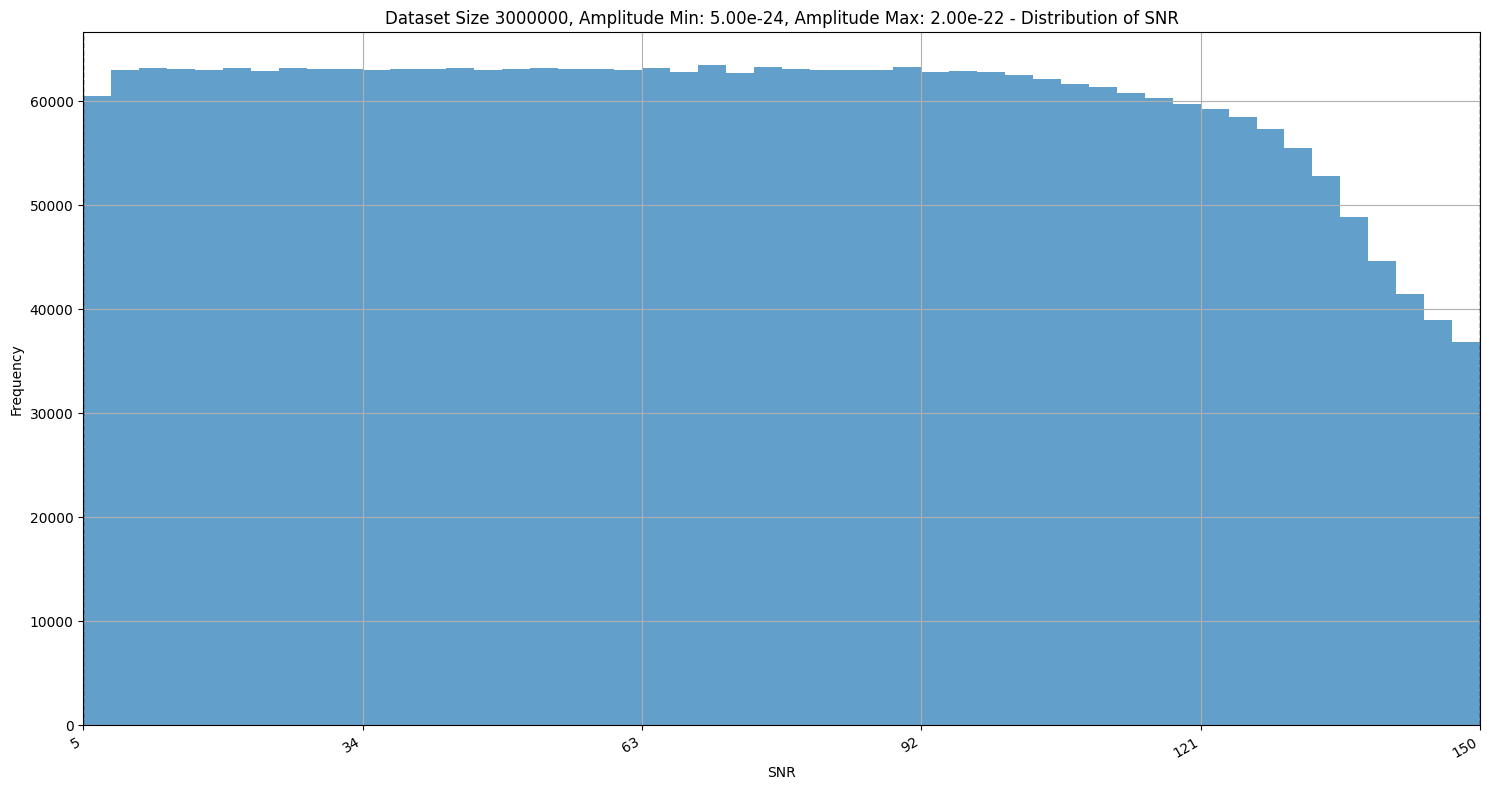

In [5]:
file_path = "../data/synthetic_dataset/dataset_3M_5.0e-24_2.0e-22_filtering_True_5_150_difficulty_1/dataset.hdf5"
load_and_plot_amp_snr(file_path)